In [1]:
!pip install pandas numpy scikit-learn openpyxl

In [2]:
import pandas as pd

train = pd.read_excel("toxic_labeled.xlsx")
test = pd.read_excel("toxic_no_label_evaluation.xlsx")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (9000, 2)
Test Shape: (1000, 2)


,text,label
0,To everyone that became an eagle today. Congra...,0
1,राहुल गांधी की रैली में 95% लोग तो केवल ये देख...,1
2,"देख लो ,ये अम्मा कांग्रेस की रजिस्टर्ड दुखियार...",1
3,We are straight but not blind best quote from ...,0
4,बोल तो ऐसे रहा है जैसे वो हल्दीघाटी का युद्ध ल...,1


In [3]:
print(train.columns)
print(test.columns)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"[^a-zA-Z0-9\s\u0900-\u097F]", "", text)  # keep Hindi + English
    return text

train['text'] = train['text'].apply(clean_text)
test['text'] = test['text'].apply(clean_text)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(train['text'])
y = train['label']

X_test = vectorizer.transform(test['text'])

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X, y)

LogisticRegression(max_iter=200)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)
pred = model.predict(X_val)

print("F1 Score:", f1_score(y_val, pred))
print(classification_report(y_val, pred))

F1 Score: 0.8747072599531616
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       938
           1       0.88      0.87      0.87       862

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.88      0.88      0.88      1800



In [8]:
test['label'] = model.predict(X_test)

In [9]:
test.to_csv("no_label.csv", index=False, encoding='utf-8-sig')

In [10]:
from google.colab import files
files.download("no_label.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ROC-AUC Score: 0.9429708616012531


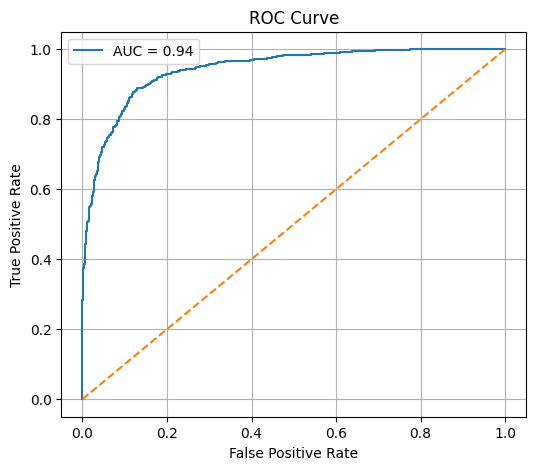

In [12]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Split your data (X = features, y = labels)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Get predicted probabilities (IMPORTANT)
y_prob = model.predict_proba(X_val)[:, 1]

# Calculate ROC-AUC score
auc = roc_auc_score(y_val, y_prob)
print("ROC-AUC Score:", auc)

# Generate ROC curve values
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

# Save image (IMPORTANT for submission)
plt.savefig("results.png")

# Show plot
plt.show()